In [1]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Models
from xgboost import XGBRegressor

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# Load the dataset
df = pd.read_csv("../data/raw/agmarknet-india-commodity-prices-2024-2025/agmarknet_india_historical_prices_2024_2025.csv")

# Display first 5 rows
print("First 5 Rows of Dataset:")
display(df.head())

# Shape of dataset
print(f"\nDataset Shape: {df.shape}")

# Column names
print("\nColumns in Dataset:")
print(df.columns.tolist())

# Basic information
print("\nDataset Information:")
df.info()

First 5 Rows of Dataset:


,Sl no.,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date,State
0,1,Auraiya,Achalda,Wheat,Dara,FAQ,2350.0,2550.0,2450.0,05 Apr 2025,Uttar Pradesh
1,2,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2500.0,2470.0,14 Jun 2025,Uttar Pradesh
2,3,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2500.0,2470.0,23 Jun 2025,Uttar Pradesh
3,4,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2520.0,2470.0,26 Jun 2025,Uttar Pradesh
4,5,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2550.0,2500.0,03 Jun 2025,Uttar Pradesh



Dataset Shape: (1118899, 11)

Columns in Dataset:
['Sl no.', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade', 'Min Price (Rs./Quintal)', 'Max Price (Rs./Quintal)', 'Modal Price (Rs./Quintal)', 'Price Date', 'State']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118899 entries, 0 to 1118898
Data columns (total 11 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Sl no.                     1118899 non-null  int64  
 1   District Name              1118899 non-null  object 
 2   Market Name                1118899 non-null  object 
 3   Commodity                  1118899 non-null  object 
 4   Variety                    1118899 non-null  object 
 5   Grade                      1118899 non-null  object 
 6   Min Price (Rs./Quintal)    1118899 non-null  float64
 7   Max Price (Rs./Quintal)    1118899 non-null  float64
 8   Modal Price (Rs./Quintal)  1118899 non-null  fl

In [4]:
# Check unique state names
print("Available States:\n")
print(df['State'].unique())

# Filter only Uttar Pradesh data
df_up = df[df['State'] == 'Uttar Pradesh']

# Reset index
df_up = df_up.reset_index(drop=True)

# Display dataset info
print(f"\nFiltered Dataset Shape: {df_up.shape}")

# Display first 5 rows
display(df_up.head())

Available States:

['Uttar Pradesh' 'West Bengal' 'Rajasthan' 'Punjab' 'Madhya Pradesh'
 'Gujarat' 'Andhra Pradesh' 'Kerala']

Filtered Dataset Shape: (402567, 11)


,Sl no.,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date,State
0,1,Auraiya,Achalda,Wheat,Dara,FAQ,2350.0,2550.0,2450.0,05 Apr 2025,Uttar Pradesh
1,2,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2500.0,2470.0,14 Jun 2025,Uttar Pradesh
2,3,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2500.0,2470.0,23 Jun 2025,Uttar Pradesh
3,4,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2520.0,2470.0,26 Jun 2025,Uttar Pradesh
4,5,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2550.0,2500.0,03 Jun 2025,Uttar Pradesh


In [5]:
# Check missing values
print("Missing Values in Each Column:\n")
print(df_up.isnull().sum())

# Remove duplicate rows
df_up = df_up.drop_duplicates()

print(f"\nDataset Shape After Removing Duplicates: {df_up.shape}")

# Fill missing values
for column in df_up.columns:
    
    # Numerical columns
    if df_up[column].dtype in ['int64', 'float64']:
        df_up[column].fillna(df_up[column].median(), inplace=True)
    
    # Categorical columns
    else:
        df_up[column].fillna(df_up[column].mode()[0], inplace=True)

# Final check
print("\nMissing Values After Cleaning:\n")
print(df_up.isnull().sum())

Missing Values in Each Column:

Sl no.                       0
District Name                0
Market Name                  0
Commodity                    0
Variety                      0
Grade                        0
Min Price (Rs./Quintal)      0
Max Price (Rs./Quintal)      0
Modal Price (Rs./Quintal)    0
Price Date                   0
State                        0
dtype: int64

Dataset Shape After Removing Duplicates: (402567, 11)

Missing Values After Cleaning:

Sl no.                       0
District Name                0
Market Name                  0
Commodity                    0
Variety                      0
Grade                        0
Min Price (Rs./Quintal)      0
Max Price (Rs./Quintal)      0
Modal Price (Rs./Quintal)    0
Price Date                   0
State                        0
dtype: int64


In [6]:
# ============================================
# DATE FEATURE ENGINEERING
# ============================================

# Rename columns
df_up = df_up.rename(columns={
    'Sl no.': 'Serial_No',
    'District Name': 'District',
    'Market Name': 'Market',
    'Commodity': 'Commodity',
    'Variety': 'Variety',
    'Grade': 'Grade',
    'Min Price (Rs./Quintal)': 'Min_Price',
    'Max Price (Rs./Quintal)': 'Max_Price',
    'Modal Price (Rs./Quintal)': 'Modal_Price',
    'Price Date': 'Price_Date',
    'State': 'State'
})

# Display updated column names
print("Updated Column Names:\n")
print(df_up.columns.tolist())

# Convert Price_Date column to datetime
df_up['Price_Date'] = pd.to_datetime(df_up['Price_Date'])

# Extract date-based features
df_up['Year'] = df_up['Price_Date'].dt.year

df_up['Month'] = df_up['Price_Date'].dt.month

df_up['Day'] = df_up['Price_Date'].dt.day

df_up['DayOfWeek'] = df_up['Price_Date'].dt.dayofweek

# Sort dataset chronologically
df_up = df_up.sort_values(by='Price_Date')

# Reset index
df_up = df_up.reset_index(drop=True)

# Display updated dataset
display(df_up.head())

Updated Column Names:

['Serial_No', 'District', 'Market', 'Commodity', 'Variety', 'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'Price_Date', 'State']


,Serial_No,District,Market,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price_Date,State,Year,Month,Day,DayOfWeek
0,8180,Muzaffarnagar,Shahpur,Bhindi(Ladies Finger),Bhindi,FAQ,1124.0,1150.0,1135.0,2024-08-15,Uttar Pradesh,2024,8,15,3
1,38313,Shahjahanpur,Puwaha,Green Chilli,Green Chilly,FAQ,3300.0,3500.0,3400.0,2024-08-15,Uttar Pradesh,2024,8,15,3
2,274,Aligarh,Aligarh,Apple,Delicious,Medium,8650.0,8850.0,8750.0,2024-08-15,Uttar Pradesh,2024,8,15,3
3,17743,Bulandshahar,Anoop Shahar,Brinjal,Round/Long,FAQ,1000.0,1400.0,1200.0,2024-08-15,Uttar Pradesh,2024,8,15,3
4,2028,Meerut,Meerut,Green Gram (Moong)(Whole),Green (Whole),FAQ,8600.0,8700.0,8660.0,2024-08-15,Uttar Pradesh,2024,8,15,3


In [7]:
# ============================================
# CREATE LAG FEATURES
# ============================================

# Create lag features using previous modal prices

df_up['Lag_1'] = df_up['Modal_Price'].shift(1)

df_up['Lag_3'] = df_up['Modal_Price'].shift(3)

df_up['Lag_7'] = df_up['Modal_Price'].shift(7)

# Rolling mean features
df_up['Rolling_Mean_3'] = df_up['Modal_Price'].rolling(window=3).mean()

df_up['Rolling_Mean_7'] = df_up['Modal_Price'].rolling(window=7).mean()

# Remove rows with NaN values created due to shifting
df_up = df_up.dropna()

# Reset index
df_up = df_up.reset_index(drop=True)

# Display dataset
display(df_up.head())

,Serial_No,District,Market,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price_Date,State,Year,Month,Day,DayOfWeek,Lag_1,Lag_3,Lag_7,Rolling_Mean_3,Rolling_Mean_7
0,33586,Gonda,Nawabganj,Apple,Delicious,Medium,9100.0,9300.0,9200.0,2024-08-15,Uttar Pradesh,2024,8,15,3,1200.0,8660.0,1135.0,4400.000000,5030.000000
1,4719,Agra,Jagnair,Bajra(Pearl Millet/Cumbu),Deshi,FAQ,2100.0,2200.0,2150.0,2024-08-15,Uttar Pradesh,2024,8,15,3,9200.0,2800.0,3400.0,4183.333333,4851.428571
2,902,Aligarh,Aligarh,Maize,Hybrid,FAQ,2300.0,2400.0,2340.0,2024-08-15,Uttar Pradesh,2024,8,15,3,2150.0,1200.0,8750.0,4563.333333,3935.714286
3,35648,Bulandshahar,Khurja,Wheat,Dara,FAQ,2475.0,2575.0,2525.0,2024-08-15,Uttar Pradesh,2024,8,15,3,2340.0,9200.0,1200.0,2338.333333,4125.000000
4,4239,Mathura,Mathura,Cabbage,Cabbage,FAQ,2100.0,2360.0,2250.0,2024-08-15,Uttar Pradesh,2024,8,15,3,2525.0,2150.0,8660.0,2371.666667,3209.285714


In [8]:
# ============================================
# FEATURE SELECTION FOR FORECASTING
# ============================================

# Select features
features = [
    'District',
    'Market',
    'Commodity',
    'Variety',
    'Year',
    'Month',
    'Day',
    'DayOfWeek',
    'Lag_1',
    'Lag_3',
    'Lag_7',
    'Rolling_Mean_3',
    'Rolling_Mean_7'
]

# Target variable
target = 'Modal_Price'

# Create feature and target datasets
X = df_up[features]

y = df_up[target]

# Display shapes
print("Feature Dataset Shape :", X.shape)

print("Target Dataset Shape :", y.shape)

# Display sample data
display(X.head())

display(y.head())

Feature Dataset Shape : (402560, 13)
Target Dataset Shape : (402560,)


,District,Market,Commodity,Variety,Year,Month,Day,DayOfWeek,Lag_1,Lag_3,Lag_7,Rolling_Mean_3,Rolling_Mean_7
0,Gonda,Nawabganj,Apple,Delicious,2024,8,15,3,1200.0,8660.0,1135.0,4400.000000,5030.000000
1,Agra,Jagnair,Bajra(Pearl Millet/Cumbu),Deshi,2024,8,15,3,9200.0,2800.0,3400.0,4183.333333,4851.428571
2,Aligarh,Aligarh,Maize,Hybrid,2024,8,15,3,2150.0,1200.0,8750.0,4563.333333,3935.714286
3,Bulandshahar,Khurja,Wheat,Dara,2024,8,15,3,2340.0,9200.0,1200.0,2338.333333,4125.000000
4,Mathura,Mathura,Cabbage,Cabbage,2024,8,15,3,2525.0,2150.0,8660.0,2371.666667,3209.285714


0    9200.0
1    2150.0
2    2340.0
3    2525.0
4    2250.0
Name: Modal_Price, dtype: float64

In [9]:
# ============================================
# ENCODE CATEGORICAL FEATURES
# ============================================

# Store encoders
label_encoders = {}

# Categorical columns
categorical_columns = [
    'District',
    'Market',
    'Commodity',
    'Variety'
]

# Apply Label Encoding
for column in categorical_columns:
    
    le = LabelEncoder()
    
    X[column] = le.fit_transform(X[column])
    
    # Save encoder
    label_encoders[column] = le

# Display encoded dataset
print("Encoded Feature Dataset:\n")

display(X.head())

Encoded Feature Dataset:



,District,Market,Commodity,Variety,Year,Month,Day,DayOfWeek,Lag_1,Lag_3,Lag_7,Rolling_Mean_3,Rolling_Mean_7
0,31,163,0,29,2024,8,15,3,1200.0,8660.0,1135.0,4400.000000,5030.000000
1,0,92,2,30,2024,8,15,3,9200.0,2800.0,3400.0,4183.333333,4851.428571
2,1,8,18,45,2024,8,15,3,2150.0,1200.0,8750.0,4563.333333,3935.714286
3,19,123,22,28,2024,8,15,3,2340.0,9200.0,1200.0,2338.333333,4125.000000
4,52,141,6,24,2024,8,15,3,2525.0,2150.0,8660.0,2371.666667,3209.285714


In [10]:
# ============================================
# TIME-BASED TRAIN TEST SPLIT
# ============================================

# Define split index
split_index = int(len(df_up) * 0.8)

# Split features
X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

# Split target
y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

# Display shapes
print("Training Feature Shape :", X_train.shape)

print("Testing Feature Shape :", X_test.shape)

print("\nTraining Target Shape :", y_train.shape)

print("Testing Target Shape :", y_test.shape)

Training Feature Shape : (322048, 13)
Testing Feature Shape : (80512, 13)

Training Target Shape : (322048,)
Testing Target Shape : (80512,)


In [11]:
# ============================================
# TRAIN FORECASTING MODEL
# ============================================

# Create XGBoost Regressor
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("Forecasting Model Trained Successfully")

Forecasting Model Trained Successfully


In [12]:
# ============================================
# FORECASTING MODEL EVALUATION
# ============================================

# Predict future prices
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

# Print evaluation results
print("Forecasting Model Evaluation Results\n")

print(f"Mean Absolute Error (MAE) : {mae:.2f}")

print(f"Mean Squared Error (MSE) : {mse:.2f}")

print(f"Root Mean Squared Error (RMSE) : {rmse:.2f}")

print(f"R2 Score : {r2:.4f}")

Forecasting Model Evaluation Results

Mean Absolute Error (MAE) : 492.29
Mean Squared Error (MSE) : 697525.09
Root Mean Squared Error (RMSE) : 835.18
R2 Score : 0.9193


,Feature,Importance
2,Commodity,0.486805
11,Rolling_Mean_3,0.236007
3,Variety,0.119541
4,Year,0.039679
5,Month,0.037681
12,Rolling_Mean_7,0.037240
8,Lag_1,0.024681
1,Market,0.006065
0,District,0.006002
6,Day,0.003310


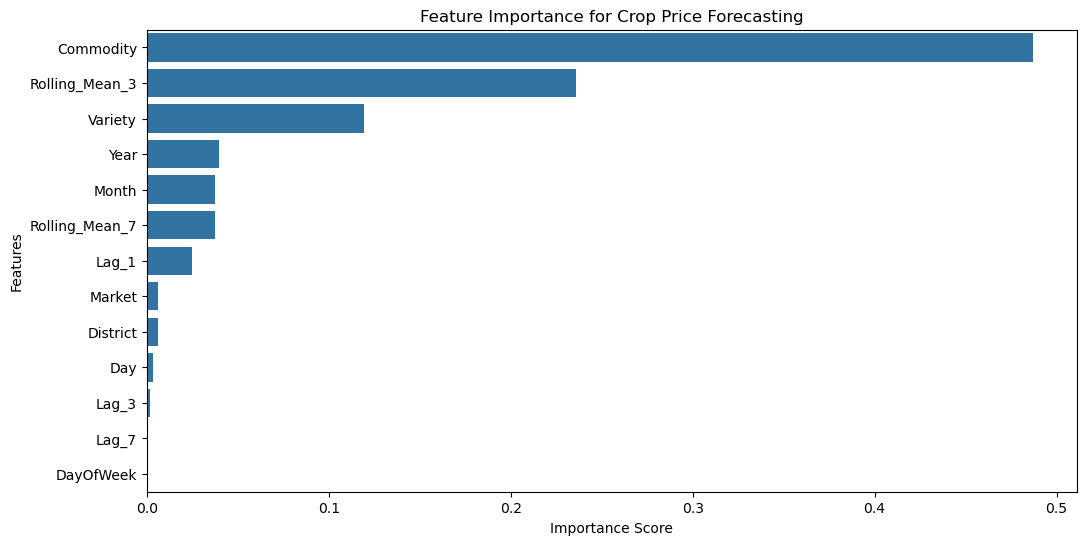

In [13]:
# ============================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================

# Get feature importance
importance = model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort features
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display importance table
display(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title("Feature Importance for Crop Price Forecasting")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

In [18]:
# ============================================
# CROP-SPECIFIC FUTURE FORECASTING
# ============================================

# Get latest row
last_row = X_test.iloc[-1:].copy()

# Get crop information
commodity_name = label_encoders['Commodity'].inverse_transform(
    [int(last_row['Commodity'].values[0])]
)[0]

market_name = label_encoders['Market'].inverse_transform(
    [int(last_row['Market'].values[0])]
)[0]

district_name = label_encoders['District'].inverse_transform(
    [int(last_row['District'].values[0])]
)[0]

# Number of future days
future_days = 7

# Store predictions
future_predictions = []

# Recursive forecasting
for i in range(future_days):

    # Predict next price
    next_pred = model.predict(last_row)[0]

    future_predictions.append(next_pred)

    # Update lag features
    last_row['Lag_7'] = last_row['Lag_3']

    last_row['Lag_3'] = last_row['Lag_1']

    last_row['Lag_1'] = next_pred

    # Update rolling means
    last_row['Rolling_Mean_3'] = (
        last_row['Lag_1'] +
        last_row['Lag_3'] +
        last_row['Lag_7']
    ) / 3

    last_row['Rolling_Mean_7'] = (
        last_row['Rolling_Mean_7'] * 6 +
        next_pred
    ) / 7

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Day': [f'Day {i+1}' for i in range(future_days)],
    'Predicted_Price': future_predictions
})

# Display crop details
print(f"Commodity : {commodity_name}")
print(f"Market     : {market_name}")
print(f"District   : {district_name}")

print("\n7-Day Future Forecast:\n")

display(forecast_df)

Commodity : Green Chilli
Market     : Gonda
District   : Gonda

7-Day Future Forecast:



,Day,Predicted_Price
0,Day 1,2966.797363
1,Day 2,2987.725830
2,Day 3,2962.457275
3,Day 4,2942.810059
4,Day 5,2944.798828
5,Day 6,2943.785645
6,Day 7,2943.210938


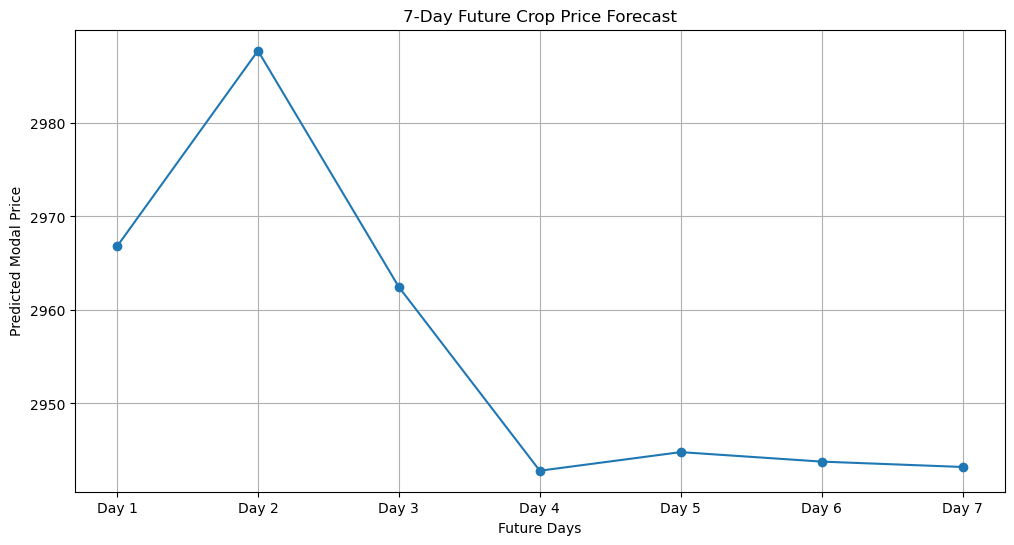

In [17]:
# ============================================
# FUTURE FORECAST VISUALIZATION
# ============================================

# Plot forecasted prices
plt.figure(figsize=(12,6))

plt.plot(
    forecast_df['Day'],
    forecast_df['Predicted_Price'],
    marker='o'
)

# Labels and title
plt.title("7-Day Future Crop Price Forecast")

plt.xlabel("Future Days")

plt.ylabel("Predicted Modal Price")

plt.grid(True)

plt.show()

In [20]:
# ============================================
# SAVE MODEL AND ENCODERS
# ============================================

import pickle

# Save trained model
with open("uttar_pradesh_crop_price_forecasting_model.pkl", "wb") as file:
    pickle.dump(model, file)

# Save label encoders
with open("uttar_pradesh_label_encoders.pkl", "wb") as file:
    pickle.dump(label_encoders, file)

print("Model and Encoders Saved Successfully")

Model and Encoders Saved Successfully
